In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox

In [52]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [54]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [55]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [56]:
skew_val = data.select_dtypes(include=['int64', 'float64']).skew()

In [57]:
skew_val.head()

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

<Axes: ylabel='charges'>

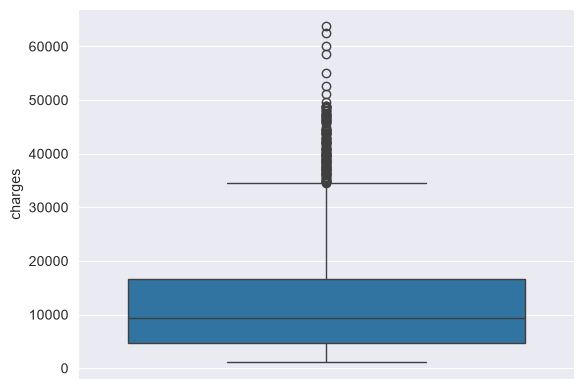

In [58]:
sns.boxplot(data['charges'])

<Axes: ylabel='bmi'>

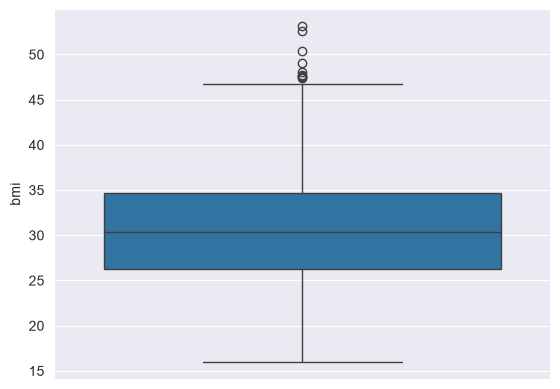

In [67]:
sns.boxplot(data['bmi'])

In [59]:
data['charges_bc'], lam = boxcox(data['charges'])
data['charges_bc'].skew()

np.float64(-0.008734083340002865)

In [60]:
print(data['sex'].unique())
print(data['smoker'].unique())
print(data['region'].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [61]:
from sklearn.preprocessing import LabelEncoder

encoder1 = LabelEncoder()

data['sex'] = encoder1.fit_transform(data['sex'])
data['smoker'] = encoder1.fit_transform(data['smoker'])
data = pd.get_dummies(data=data, columns=['region'], drop_first=True)

In [62]:
data.head()

,age,sex,bmi,children,smoker,charges,charges_bc,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,12.128980,False,False,True
1,18,1,33.770,1,0,1725.55230,8.808597,False,True,False
2,28,1,33.000,3,0,4449.46200,10.147521,False,True,False
3,33,1,22.705,0,0,21984.47061,12.534951,True,False,False
4,32,1,28.880,0,0,3866.85520,9.945637,True,False,False


In [63]:
data.corr()

,age,sex,bmi,children,smoker,charges,charges_bc,region_northwest,region_southeast,region_southwest
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008,0.518644,-0.000407,-0.011642,0.010016
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292,0.008695,-0.011156,0.017117,-0.004184
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341,0.135792,-0.135996,0.270025,-0.006205
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998,0.156310,0.024806,-0.023066,0.021914
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251,0.675661,-0.036945,0.068498,-0.036945
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000,0.902821,-0.039905,0.073982,-0.043210
charges_bc,0.518644,0.008695,0.135792,0.156310,0.675661,0.902821,1.000000,-0.019210,0.018994,-0.041956
region_northwest,-0.000407,-0.011156,-0.135996,0.024806,-0.036945,-0.039905,-0.019210,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,0.017117,0.270025,-0.023066,0.068498,0.073982,0.018994,-0.346265,1.000000,-0.346265
region_southwest,0.010016,-0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.041956,-0.320829,-0.346265,1.000000


In [64]:
print(data.drop(columns=['charges_bc']).corr(numeric_only=True)['charges'].sort_values(ascending=False))

charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [65]:
print(data.drop(columns=['charges']).corr(numeric_only=True)['charges_bc'].sort_values(ascending=False))

charges_bc          1.000000
smoker              0.675661
age                 0.518644
children            0.156310
bmi                 0.135792
region_southeast    0.018994
sex                 0.008695
region_northwest   -0.019210
region_southwest   -0.041956
Name: charges_bc, dtype: float64


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = data.drop(columns=['charges', 'charges_bc'])
y = data['charges_bc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [69]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_p = poly.fit_transform(X_train_s)
X_test_p = poly.transform(X_test_s)

X_train_p.shape

(1070, 164)

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

base = LinearRegression()
base.fit(X_train_p, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](164,)","[ 1.16,-0.05, 0.25,..., 0. , 0. ,-0.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,164
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(100)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](164,)","[62.12,48.57,36.28,..., 0. , 0. , 0. ]"


In [72]:
base.score(X_test_p, y_test)

0.854850221125833

In [83]:
base_no_poly = LinearRegression()

scores1 = cross_val_score(base, X_train_p , y_train, cv=5, scoring='r2')
scores2 = cross_val_score(base_no_poly, X_train, y_train, cv=5, scoring='r2')

In [84]:
pd.DataFrame(scores1)

,0
0,0.789948
1,0.886833
2,0.787116
3,0.771583
4,0.816898


In [85]:
pd.DataFrame(scores2)

,0
0,0.717155
1,0.818564
2,0.756137
3,0.700336
4,0.779882


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('rs', RobustScaler()),
    ('poly', PolynomialFeatures()),
    ('model', Lasso())
])

param_grid = {
    'poly__degree': [1, 2, 3],
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...], 'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inf

In [77]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_poly__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004065,0.001203,0.001436,0.000429,0.001,1,"{'model__alpha': 0.001, 'poly__degree': 1}",0.717177,0.818982,0.756331,0.699570,0.779928,0.754398,0.042937,5
1,0.003517,0.000367,0.001269,0.000131,0.001,2,"{'model__alpha': 0.001, 'poly__degree': 2}",0.793556,0.891160,0.814557,0.789539,0.832203,0.824203,0.036827,1
2,0.006285,0.000661,0.001607,0.000333,0.001,3,"{'model__alpha': 0.001, 'poly__degree': 3}",0.796140,0.889874,0.804229,0.784219,0.829035,0.820700,0.037576,2
3,0.003222,0.000336,0.001179,0.000175,0.010,1,"{'model__alpha': 0.01, 'poly__degree': 1}",0.715502,0.819006,0.757397,0.692692,0.777745,0.752469,0.044789,6
4,0.003290,0.000345,0.001270,0.000144,0.010,2,"{'model__alpha': 0.01, 'poly__degree': 2}",0.778247,0.884431,0.814754,0.771993,0.829898,0.815865,0.040594,4
5,0.004547,0.000360,0.001729,0.000382,0.010,3,"{'model__alpha': 0.01, 'poly__degree': 3}",0.779276,0.885266,0.815118,0.772861,0.830722,0.816649,0.040553,3
6,0.003358,0.000846,0.001093,0.000085,0.100,1,"{'model__alpha': 0.1, 'poly__degree': 1}",0.648687,0.733667,0.698042,0.640965,0.684914,0.681255,0.033841,7
7,0.003514,0.000639,0.001230,0.000138,0.100,2,"{'model__alpha': 0.1, 'poly__degree': 2}",0.648687,0.733667,0.698042,0.640965,0.684914,0.681255,0.033841,7
8,0.004159,0.000638,0.001301,0.000117,0.100,3,"{'model__alpha': 0.1, 'poly__degree': 3}",0.648687,0.733667,0.696491,0.640965,0.684914,0.680945,0.033693,9
9,0.003235,0.000510,0.001223,0.000171,1.000,1,"{'model__alpha': 1, 'poly__degree': 1}",-0.001162,-0.015471,-0.001313,-0.000004,-0.014796,-0.006549,0.007027,10


In [79]:
print(grid.best_estimator_)

Pipeline(steps=[('rs', RobustScaler()), ('poly', PolynomialFeatures()),
                ('model', Lasso(alpha=0.001))])


In [80]:
print(grid.best_params_)
print(grid.best_score_)

{'model__alpha': 0.001, 'poly__degree': 2}
0.824202923879912


In [81]:
scores = cross_val_score(grid.best_estimator_, X_train, y_train, cv=5, scoring='r2')

In [82]:
pd.DataFrame(scores)

,0
0,0.793556
1,0.891160
2,0.814557
3,0.789539
4,0.832203


In [86]:
from sklearn.linear_model import Ridge, ElasticNet

pipe_ridge = Pipeline([
    ('rs', RobustScaler()),
    ('poly', PolynomialFeatures()),
    ('model', Ridge())
])
param_grid_ridge = {'poly__degree': [1,2,3], 'model__alpha': [0.001,0.01,0.1,1,10,100]}
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

pipe_elastic = Pipeline([
    ('rs', RobustScaler()),
    ('poly', PolynomialFeatures()),
    ('model', ElasticNet(max_iter=10000))
])
param_grid_elastic = {
    'poly__degree': [1,2,3],
    'model__alpha': [0.001,0.01,0.1,1,10,100],
    'model__l1_ratio': [0.1,0.3,0.5,0.7,0.9]
}
grid_elastic = GridSearchCV(pipe_elastic, param_grid_elastic, cv=5, scoring='r2')
grid_elastic.fit(X_train, y_train)

print("Lasso:", grid.best_score_, grid.best_params_)
print("Ridge:", grid_ridge.best_score_, grid_ridge.best_params_)
print("ElasticNet:", grid_elastic.best_score_, grid_elastic.best_params_)

Lasso: 0.824202923879912 {'model__alpha': 0.001, 'poly__degree': 2}
Ridge: 0.8238419426762251 {'model__alpha': 1, 'poly__degree': 2}
ElasticNet: 0.8242054758953717 {'model__alpha': 0.001, 'model__l1_ratio': 0.9, 'poly__degree': 2}


In [87]:
best_model = grid.best_estimator_  # your Lasso grid
lasso_step = best_model.named_steps['model']
poly_step = best_model.named_steps['poly']
feature_names = poly_step.get_feature_names_out(X_train.columns)

for name, coef in zip(feature_names, lasso_step.coef_):
    if coef != 0:
        print(f"{name}: {coef:.4f}")

age: 1.3330
sex: -0.0473
bmi: 0.1004
children: 0.4164
smoker: 2.2582
region_northwest: -0.0301
region_southeast: -0.1115
region_southwest: -0.1306
age^2: -0.1173
age sex: 0.1405
age bmi: -0.0286
age children: -0.2835
age smoker: -1.0864
age region_northwest: 0.0623
age region_southeast: 0.2196
age region_southwest: 0.2662
sex^2: 0.1360
sex bmi: 0.0349
sex smoker: 0.0991
sex region_northwest: 0.0933
sex region_southeast: 0.0747
bmi^2: -0.0594
bmi smoker: 0.6565
bmi region_northwest: -0.0637
bmi region_southeast: -0.0844
bmi region_southwest: -0.0601
children^2: -0.0822
children smoker: -0.3334
children region_northwest: 0.0050
children region_southeast: -0.0248
children region_southwest: -0.0885
smoker^2: 0.0002
smoker region_southeast: 0.0320
smoker region_southwest: 0.2376
region_northwest^2: -0.0102
region_southeast^2: -0.0058
region_southwest^2: -0.1198


In [88]:
from scipy.special import inv_boxcox
from sklearn.metrics import r2_score, mean_squared_error

y_pred_bc = best_model.predict(X_test)
y_pred_dollars = inv_boxcox(y_pred_bc, lam)
y_test_dollars = inv_boxcox(y_test, lam)

print("Test R² (dollars):", r2_score(y_test_dollars, y_pred_dollars))
print("Test RMSE (dollars):", np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars)))

Test R² (dollars): 0.8620587198423654
Test RMSE (dollars): 4627.656941133831


In [90]:
train_r2 = best_model.score(X_train, y_train)
test_r2 = r2_score(y_test_dollars, y_pred_dollars)  # or on the bc scale for apples-to-apples
print(f"Train: {train_r2:.3f}, Test: {test_r2:.3f}")

Train: 0.835, Test: 0.862
